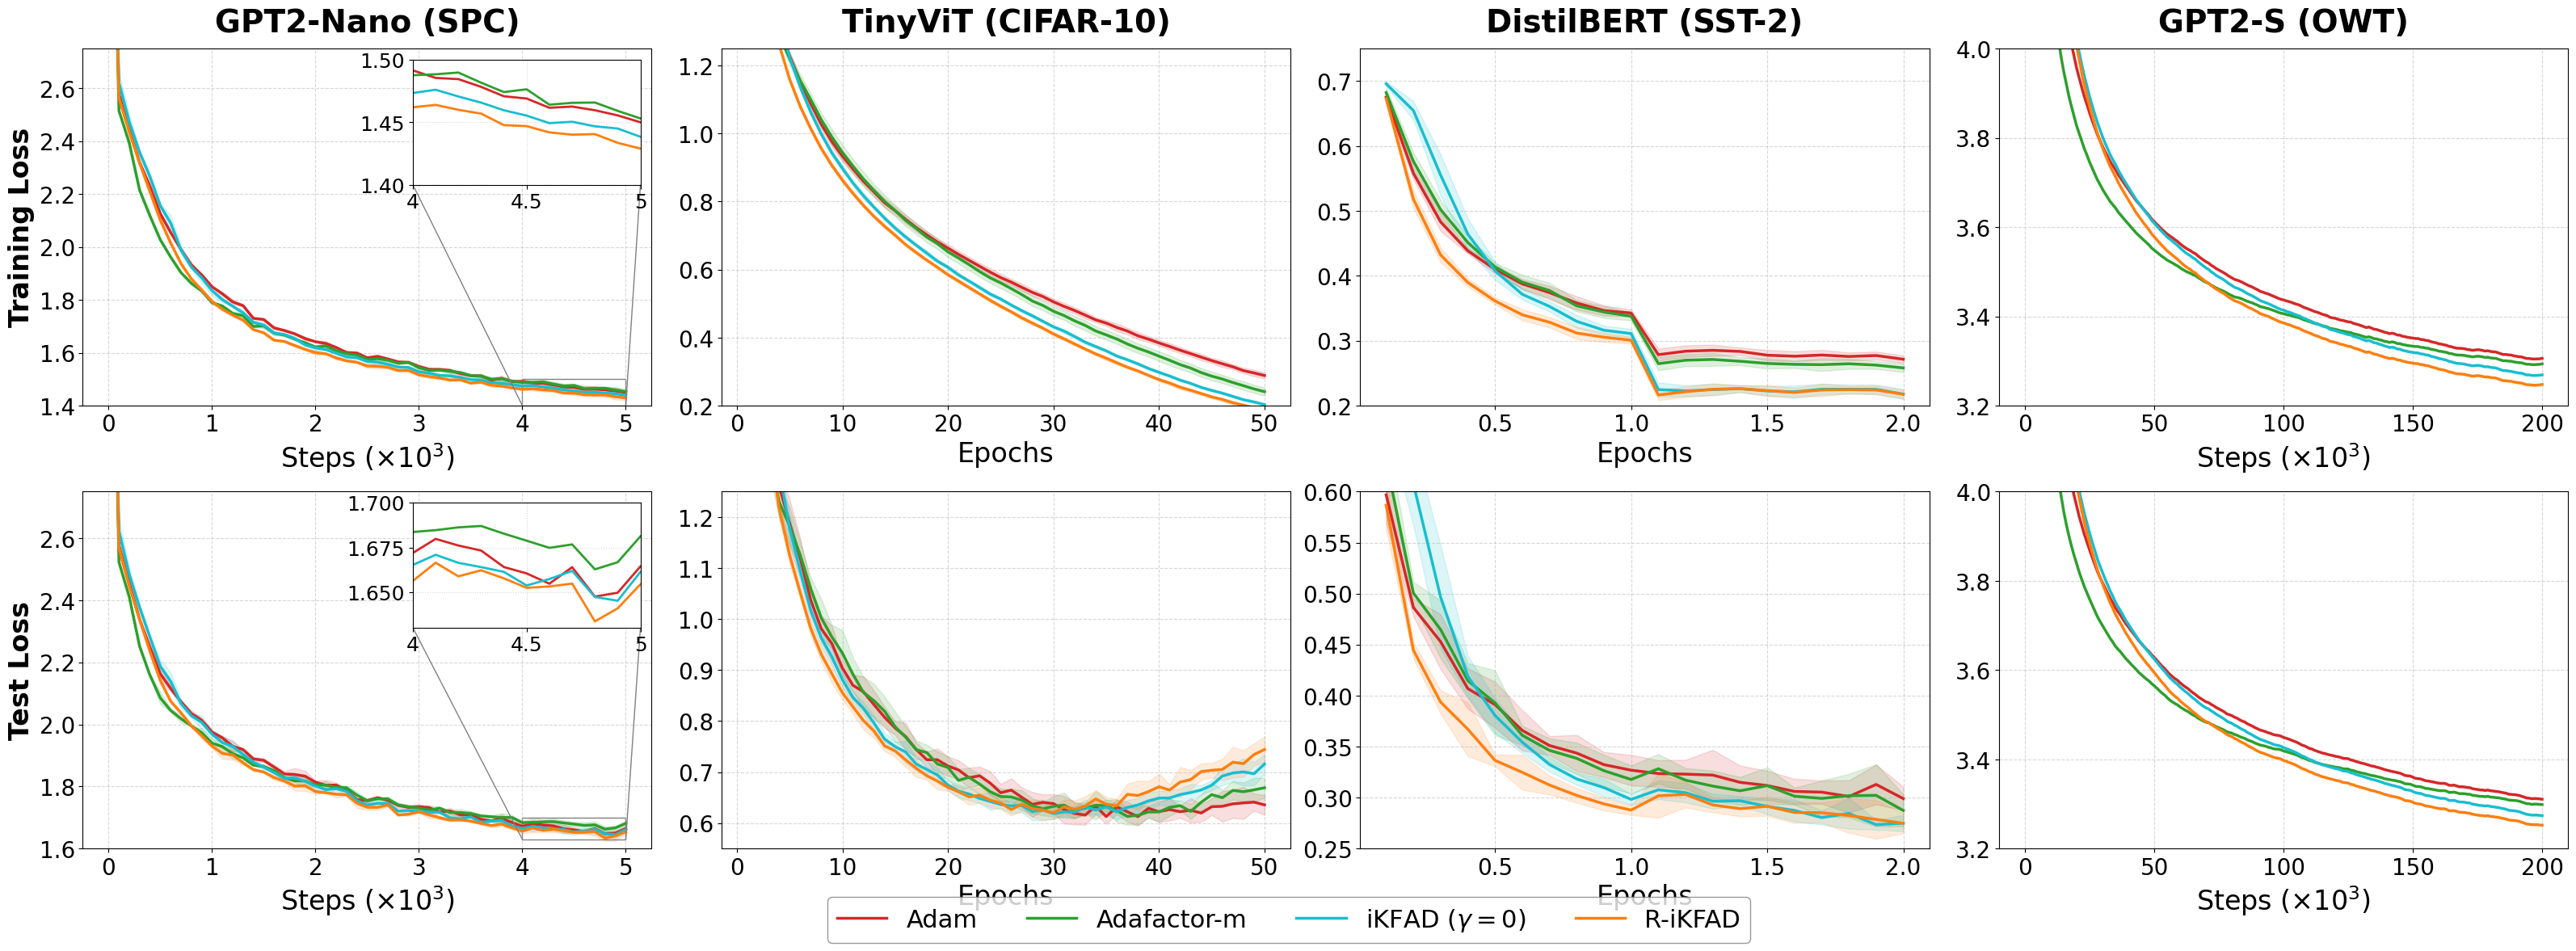

In [1]:
import os
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import FuncFormatter
from scipy.ndimage import uniform_filter1d

# --- Global Configuration ---
ALL_OPTIMIZERS = ['adam', 'adafactor', 'ikfad0', 'rikfad0']

COLORS = {
    'rikfad0':   '#ff7f0e',   # orange
    'ikfad0':    '#17becf',   # cyan
    'adafactor': '#2ca02c',   # green
    'adam':      '#d62728',   # red
}

DISPLAY_NAMES = {
    'rikfad0':   'R-iKFAD',
    'ikfad0':    r'iKFAD ($\gamma=0$)',
    'adafactor': 'Adafactor-m',
    'adam':      'Adam',
}

FONT_SIZES = {
    'title':  28,
    'label':  24,
    'tick':   20,
    'legend': 22,
}

ZOOM_SETTINGS = {
    'GPT2-Nano (SPC)': {
        'train': {'xlim': (4000, 5000), 'ylim': (1.4,  1.5)},
        'val':   {'xlim': (4000, 5000), 'ylim': (1.63, 1.7)}
    }
}

fig, axes = plt.subplots(2, 4, figsize=(32, 12))

def get_csv_data(base_dir, opt_name, start_epoch_cut=0, first_seed_only=False, index_mode='epoch'):
    file_path = os.path.join(base_dir, 'sweep-table', f'{opt_name}.csv')
    if not os.path.exists(file_path):
        return None
    df = pd.read_csv(file_path)
    metrics_map = {'train_loss': 'train', 'valid_loss': 'val', 'step': 'step'}
    try:
        data_arrays = {}
        min_len = float('inf')
        available_cols = [c for c in metrics_map if c in df.columns]
        if not available_cols:
            return None
        for csv_col in available_cols:
            internal_key = metrics_map[csv_col]
            if first_seed_only:
                val = ast.literal_eval(df[csv_col].iloc[0])
                data_arrays[internal_key] = [val]
                min_len = min(min_len, len(val))
            else:
                vals = df[csv_col].apply(ast.literal_eval).tolist()
                data_arrays[internal_key] = vals
                min_len = min(min_len, min(len(x) for x in vals))
        if min_len == float('inf') or min_len == 0:
            return None
        n = int(min_len)
        if 'step' in data_arrays:
            x_axis = np.array(data_arrays['step'][0][:n])
        elif index_mode == 'epoch':
            x_axis = np.arange(1, n + 1)
        else:
            x_axis = np.arange(n)
        result = {'x': x_axis[start_epoch_cut:]}
        for key in ['train', 'val']:
            if key not in data_arrays:
                continue
            raw = data_arrays[key]
            if first_seed_only:
                mean = np.array(raw[0][:n])
                std  = np.zeros(n)
            else:
                stack = np.stack([x[:n] for x in raw])
                mean, std = np.mean(stack, axis=0), np.std(stack, axis=0)
            result[f'{key}_mean'] = mean[start_epoch_cut:]
            result[f'{key}_std']  = std[start_epoch_cut:]
        return result
    except Exception as e:
        print(f'Error reading {base_dir}/{opt_name}: {e}')
        return None

dataset_specs = [
    {
        'title':     'GPT2-Nano (SPC)',
        'fetcher':   lambda opt: get_csv_data('nano', opt),
        'whitelist': ['adam', 'adafactor', 'ikfad0', 'rikfad0'],
        'xlabel':    r'Steps ($\times 10^3$)',
        'ylims':     {'train': (1.4, 2.75), 'val': (1.6, 2.75)},
        'x_divisor': 1,
    },
    {
        'title':     'TinyViT (CIFAR-10)',
        'fetcher':   lambda opt: get_csv_data('vit', opt),
        'whitelist': ['adam', 'adafactor', 'ikfad0', 'rikfad0'],
        'xlabel':    'Epochs',
        'ylims':     {'train': (0.2, 1.25), 'val': (0.55, 1.25)},
        'x_divisor': 1,
    },
    {
        'title':     'DistilBERT (SST-2)',
        'fetcher':   lambda opt: get_csv_data('sst2', opt),
        'whitelist': ['adam', 'adafactor', 'ikfad0', 'rikfad0'],
        'xlabel':    'Epochs',
        'ylims':     {'train': (0.2, 0.75), 'val': (0.25, 0.6)},
        'x_divisor': 10,  # 20 eval points over 2 epochs
    },
    {
        'title':     'GPT2-S (OWT)',
        'fetcher':   lambda opt: get_csv_data('owt_gpt2s', opt),
        'whitelist': ['adam', 'adafactor', 'ikfad0', 'rikfad0'],
        'xlabel':    r'Steps ($\times 10^3$)',
        'ylims':     {'train': (3.2, 4.0), 'val': (3.2, 4.0)},
        'x_divisor': 1,
        'smooth':    15,  # uniform moving-average window (single-seed run)
    },
]

kilo_formatter = FuncFormatter(lambda x, pos: f'{x/1000:g}')
legend_lines, legend_labels = [], []

for col_idx, spec in enumerate(dataset_specs):
    ax_train, ax_val = axes[0, col_idx], axes[1, col_idx]
    title = spec['title']
    x_div = spec.get('x_divisor', 1)
    smooth = spec.get('smooth', None)
    zs = ZOOM_SETTINGS.get(title, {})

    axins_train = inset_axes(ax_train, width='40%', height='35%', loc='upper right', borderpad=1) if 'train' in zs else None
    axins_val   = inset_axes(ax_val,   width='40%', height='35%', loc='upper right', borderpad=1) if 'val'   in zs else None

    ax_train.set_title(title, fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
    if col_idx == 0:
        ax_train.set_ylabel('Training Loss', fontsize=FONT_SIZES['label'], fontweight='bold')
        ax_val.set_ylabel('Test Loss',       fontsize=FONT_SIZES['label'], fontweight='bold')

    ax_train.set_ylim(spec['ylims']['train'])
    ax_val.set_ylim(spec['ylims']['val'])

    for opt in ALL_OPTIMIZERS:
        if opt not in spec['whitelist']:
            continue
        data = spec['fetcher'](opt)
        if data is None:
            continue
        c         = COLORS.get(opt, 'black')
        lbl       = DISPLAY_NAMES.get(opt, opt)
        x         = data['x'] / x_div
        y_tr      = data['train_mean']
        y_val     = data['val_mean']
        y_tr_std  = data['train_std']
        y_val_std = data['val_std']

        if smooth:
            y_tr      = uniform_filter1d(y_tr,      size=smooth)
            y_val     = uniform_filter1d(y_val,     size=smooth)
            y_tr_std  = uniform_filter1d(y_tr_std,  size=smooth)
            y_val_std = uniform_filter1d(y_val_std, size=smooth)

        l1, = ax_train.plot(x, y_tr,  label=lbl, color=c, linewidth=2.5)
        ax_train.fill_between(x, y_tr  - y_tr_std,  y_tr  + y_tr_std,  color=c, alpha=0.15)
        ax_val.plot(x, y_val, label=lbl, color=c, linewidth=2.5)
        ax_val.fill_between(x, y_val - y_val_std, y_val + y_val_std, color=c, alpha=0.15)

        if axins_train: axins_train.plot(x, y_tr,  color=c, linewidth=2)
        if axins_val:   axins_val.plot(  x, y_val, color=c, linewidth=2)

        if lbl not in legend_labels:
            legend_lines.append(l1); legend_labels.append(lbl)

    for axins, z_key in [(axins_train, 'train'), (axins_val, 'val')]:
        if axins:
            axins.set_xlim(zs[z_key]['xlim']); axins.set_ylim(zs[z_key]['ylim'])
            parent = ax_train if z_key == 'train' else ax_val
            mark_inset(parent, axins, loc1=3, loc2=4, fc='none', ec='0.5')
            axins.grid(True, linestyle=':', alpha=0.5)
            axins.tick_params(labelsize=FONT_SIZES['tick'] - 2)
            axins.xaxis.set_major_formatter(kilo_formatter)
            axins.set_xticks([4000, 4500, 5000])

    for ax in [ax_train, ax_val]:
        ax.set_xlabel(spec['xlabel'], fontsize=FONT_SIZES['label'])
        ax.tick_params(labelsize=FONT_SIZES['tick'])
        ax.grid(True, linestyle='--', alpha=0.5)
        if 'GPT2' in title:
            ax.xaxis.set_major_formatter(kilo_formatter)

fig.legend(legend_lines, legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, 0.01),
           ncol=len(legend_labels), fontsize=FONT_SIZES['legend'],
           frameon=True, fancybox=True, edgecolor='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig('figs/results.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.show()

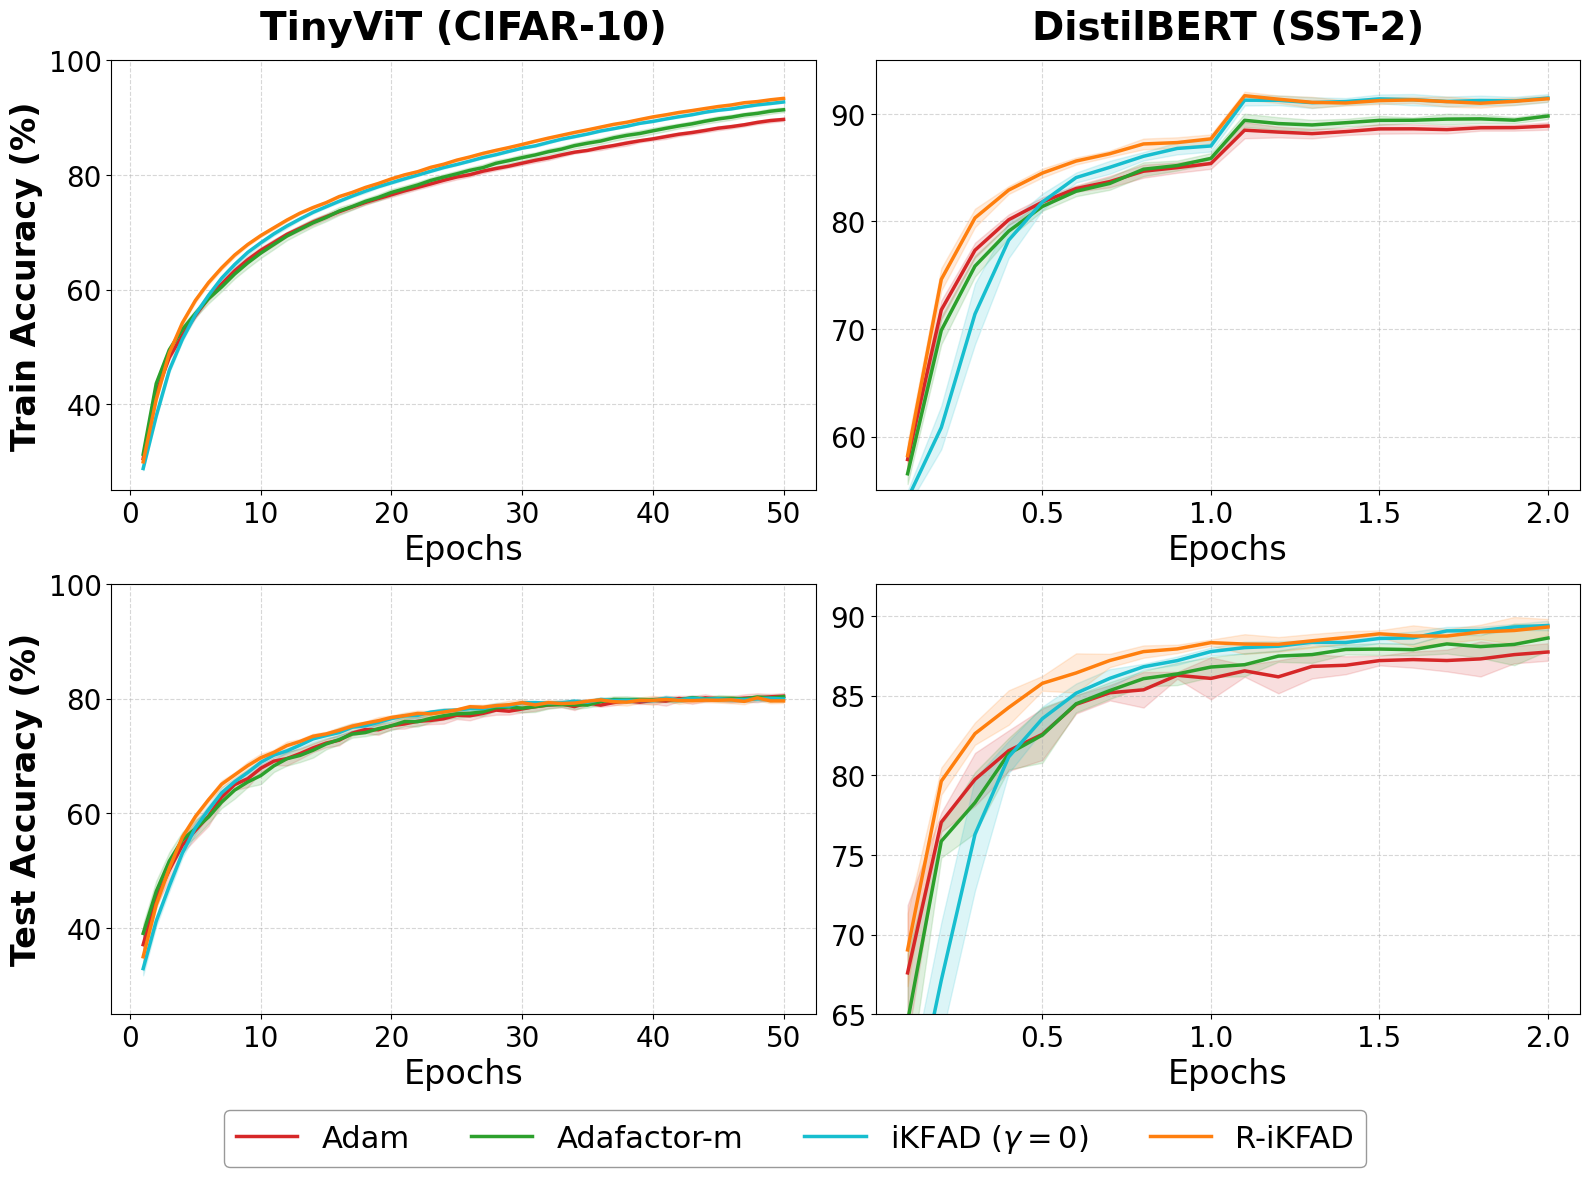

In [3]:
import os
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Global Configuration ---
ALL_OPTIMIZERS = ['adam', 'adafactor', 'ikfad0', 'rikfad0']

COLORS = {
    'rikfad0':   '#ff7f0e',
    'ikfad0':    '#17becf',
    'adafactor': '#2ca02c',
    'adam':      '#d62728',
}

DISPLAY_NAMES = {
    'rikfad0':   'R-iKFAD',
    'ikfad0':    r'iKFAD ($\gamma=0$)',
    'adafactor': 'Adafactor-m',
    'adam':      'Adam',
}

FONT_SIZES = {
    'title':  28,
    'label':  24,
    'tick':   20,
    'legend': 22,
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

def get_acc_data(base_dir, opt_name):
    file_path = os.path.join(base_dir, 'sweep-table', f'{opt_name}.csv')
    if not os.path.exists(file_path):
        return None
    df = pd.read_csv(file_path)
    metrics_map = {'train_acc': 'train', 'valid_acc': 'val'}
    try:
        data_arrays = {}
        min_len = float('inf')
        available_cols = [c for c in metrics_map if c in df.columns]
        if not available_cols:
            return None
        for csv_col in available_cols:
            internal_key = metrics_map[csv_col]
            vals = df[csv_col].apply(ast.literal_eval).tolist()
            data_arrays[internal_key] = vals
            min_len = min(min_len, min(len(x) for x in vals))
        if min_len == float('inf') or min_len == 0:
            return None
        n = int(min_len)
        x_axis = np.arange(1, n + 1)
        result = {'x': x_axis}
        for key in ['train', 'val']:
            if key not in data_arrays:
                continue
            stack = np.stack([x[:n] for x in data_arrays[key]])
            result[f'{key}_mean'] = np.mean(stack, axis=0)
            result[f'{key}_std']  = np.std(stack,  axis=0)
        return result
    except Exception as e:
        print(f'Error reading {base_dir}/{opt_name}: {e}')
        return None

dataset_specs = [
    {
        'title':     'TinyViT (CIFAR-10)',
        'fetcher':   lambda opt: get_acc_data('vit', opt),
        'whitelist': ['adam', 'adafactor', 'ikfad0', 'rikfad0'],
        'xlabel':    'Epochs',
        'ylims':     {'train': (25, 100), 'val': (25, 100)},
        'x_divisor': 1,
    },
    {
        'title':     'DistilBERT (SST-2)',
        'fetcher':   lambda opt: get_acc_data('sst2', opt),
        'whitelist': ['adam', 'adafactor', 'ikfad0', 'rikfad0'],
        'xlabel':    'Epochs',
        'ylims':     {'train': (55, 95), 'val': (65, 92)},
        'x_divisor': 10,  # 20 eval points over 2 epochs
    },
]

legend_lines, legend_labels = [], []

for col_idx, spec in enumerate(dataset_specs):
    ax_train, ax_val = axes[0, col_idx], axes[1, col_idx]
    title = spec['title']
    x_div = spec.get('x_divisor', 1)

    ax_train.set_title(title, fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
    if col_idx == 0:
        ax_train.set_ylabel('Train Accuracy (%)', fontsize=FONT_SIZES['label'], fontweight='bold')
        ax_val.set_ylabel('Test Accuracy (%)',    fontsize=FONT_SIZES['label'], fontweight='bold')

    ax_train.set_ylim(spec['ylims']['train'])
    ax_val.set_ylim(spec['ylims']['val'])

    for opt in ALL_OPTIMIZERS:
        if opt not in spec['whitelist']:
            continue
        data = spec['fetcher'](opt)
        if data is None:
            continue
        c         = COLORS.get(opt, 'black')
        lbl       = DISPLAY_NAMES.get(opt, opt)
        x         = data['x'] / x_div
        y_tr      = data['train_mean']
        y_val     = data['val_mean']
        y_tr_std  = data['train_std']
        y_val_std = data['val_std']

        l1, = ax_train.plot(x, y_tr,  label=lbl, color=c, linewidth=2.5)
        ax_train.fill_between(x, y_tr  - y_tr_std,  y_tr  + y_tr_std,  color=c, alpha=0.15)
        ax_val.plot(x, y_val, label=lbl, color=c, linewidth=2.5)
        ax_val.fill_between(x, y_val - y_val_std, y_val + y_val_std, color=c, alpha=0.15)

        if lbl not in legend_labels:
            legend_lines.append(l1); legend_labels.append(lbl)

    for ax in [ax_train, ax_val]:
        ax.set_xlabel(spec['xlabel'], fontsize=FONT_SIZES['label'])
        ax.tick_params(labelsize=FONT_SIZES['tick'])
        ax.grid(True, linestyle='--', alpha=0.5)

fig.legend(legend_lines, legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, 0.01),
           ncol=len(legend_labels), fontsize=FONT_SIZES['legend'],
           frameon=True, fancybox=True, edgecolor='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('figs/results_acc.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.show()

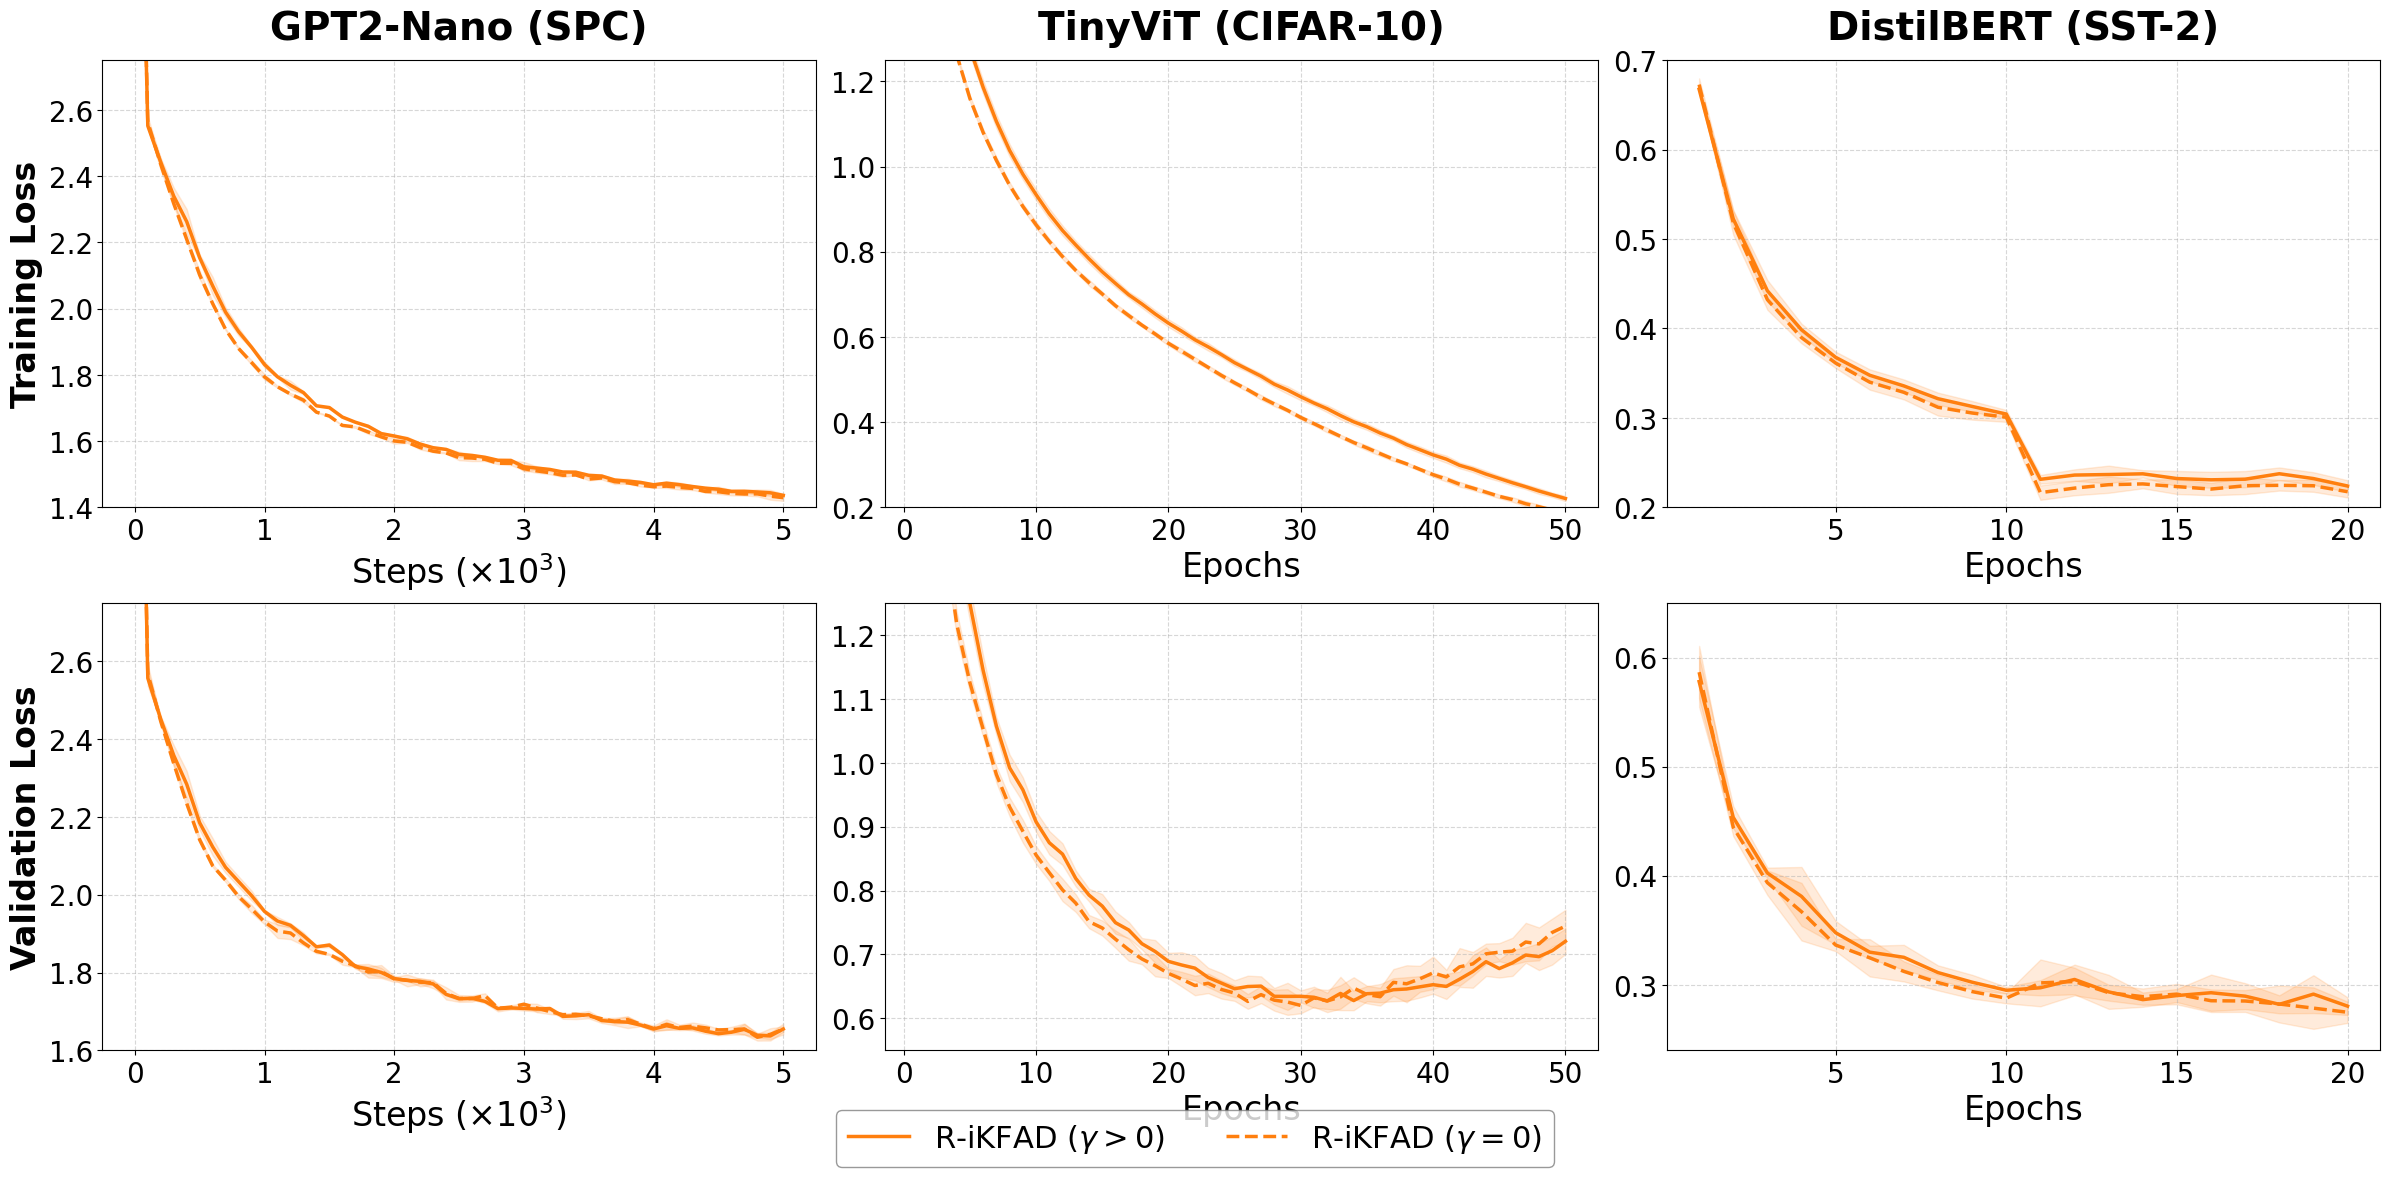

In [4]:
import os
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- rikfad vs rikfad0 ablation (gamma > 0 vs gamma = 0) ---

COLOR = '#ff7f0e'  # same orange for both — linestyle distinguishes them

FONT_SIZES = {'title': 28, 'label': 24, 'tick': 20, 'legend': 22}

def get_csv_data(base_dir, opt_name):
    file_path = os.path.join(base_dir, 'sweep-table', f'{opt_name}.csv')
    if not os.path.exists(file_path):
        return None
    df = pd.read_csv(file_path)
    metrics_map = {'train_loss': 'train', 'valid_loss': 'val', 'step': 'step'}
    try:
        data_arrays = {}
        min_len = float('inf')
        available_cols = [c for c in metrics_map if c in df.columns]
        if not available_cols:
            return None
        for csv_col in available_cols:
            internal_key = metrics_map[csv_col]
            vals = df[csv_col].apply(ast.literal_eval).tolist()
            data_arrays[internal_key] = vals
            min_len = min(min_len, min(len(x) for x in vals))
        if min_len == float('inf') or min_len == 0:
            return None
        n = int(min_len)
        if 'step' in data_arrays:
            x_axis = np.array(data_arrays['step'][0][:n])
        else:
            x_axis = np.arange(1, n + 1)
        result = {'x': x_axis}
        for key in ['train', 'val']:
            if key not in data_arrays:
                continue
            stack = np.stack([x[:n] for x in data_arrays[key]])
            result[f'{key}_mean'] = np.mean(stack, axis=0)
            result[f'{key}_std']  = np.std(stack,  axis=0)
        return result
    except Exception as e:
        print(f'Error reading {base_dir}/{opt_name}: {e}')
        return None

dataset_specs = [
    {
        'title':  'GPT2-Nano (SPC)',
        'base':   'nano',
        'xlabel': r'Steps ($\times 10^3$)',
        'ylims':  {'train': (1.4, 2.75), 'val': (1.6, 2.75)},
        'kilo':   True,
    },
    {
        'title':  'TinyViT (CIFAR-10)',
        'base':   'vit',
        'xlabel': 'Epochs',
        'ylims':  {'train': (0.2, 1.25), 'val': (0.55, 1.25)},
        'kilo':   False,
    },
    {
        'title':  'DistilBERT (SST-2)',
        'base':   'sst2',
        'xlabel': 'Epochs',
        'ylims':  {'train': (0.20, 0.70), 'val': (0.24, 0.65)},
        'kilo':   False,
    },
]

kilo_formatter = FuncFormatter(lambda x, pos: f'{x/1000:g}')
fig, axes = plt.subplots(2, 3, figsize=(24, 12))

legend_lines, legend_labels = [], []

for col_idx, spec in enumerate(dataset_specs):
    ax_tr  = axes[0, col_idx]
    ax_val = axes[1, col_idx]

    ax_tr.set_title(spec['title'], fontsize=FONT_SIZES['title'], fontweight='bold', pad=15)
    if col_idx == 0:
        ax_tr.set_ylabel('Training Loss',   fontsize=FONT_SIZES['label'], fontweight='bold')
        ax_val.set_ylabel('Validation Loss', fontsize=FONT_SIZES['label'], fontweight='bold')

    ax_tr.set_ylim(spec['ylims']['train'])
    ax_val.set_ylim(spec['ylims']['val'])

    for opt, ls, lbl in [('rikfad',  '-',  r'R-iKFAD ($\gamma > 0$)'),
                          ('rikfad0', '--', r'R-iKFAD ($\gamma = 0$)')]:
        data = get_csv_data(spec['base'], opt)
        if data is None:
            continue
        x       = data['x']
        y_tr    = data['train_mean']
        y_val   = data['val_mean']
        y_tr_s  = data['train_std']
        y_val_s = data['val_std']

        l, = ax_tr.plot(x, y_tr,  color=COLOR, linestyle=ls, linewidth=2.5, label=lbl)
        ax_tr.fill_between(x, y_tr  - y_tr_s,  y_tr  + y_tr_s,  color=COLOR, alpha=0.15)
        ax_val.plot(x, y_val, color=COLOR, linestyle=ls, linewidth=2.5)
        ax_val.fill_between(x, y_val - y_val_s, y_val + y_val_s, color=COLOR, alpha=0.15)

        if lbl not in legend_labels:
            legend_lines.append(l); legend_labels.append(lbl)

    for ax in [ax_tr, ax_val]:
        ax.set_xlabel(spec['xlabel'], fontsize=FONT_SIZES['label'])
        ax.tick_params(labelsize=FONT_SIZES['tick'])
        ax.grid(True, linestyle='--', alpha=0.5)
        if spec['kilo']:
            ax.xaxis.set_major_formatter(kilo_formatter)

fig.legend(legend_lines, legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, 0.01),
           ncol=2, fontsize=FONT_SIZES['legend'],
           frameon=True, fancybox=True, edgecolor='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig('figs/results_ablation.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.show()